In [ ]:
# Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [ ]:
# Step 2: Load the dataset and perform initial inspection

# Load the data
file_path = '/content/drive/MyDrive/crime/Copy of Bangladesh-Crime-Dataset.csv'
df = pd.read_csv(file_path)

print("=" * 60)
print("DATA LOADING - INITIAL INSPECTION")
print("=" * 60)

# Check basic info
print(f"\nDataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Show first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Remove unnamed index column if exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("\n✓ Removed 'Unnamed: 0' column")

print(f"\n✓ Final dataset shape: {df.shape}")

DATA LOADING - INITIAL INSPECTION

Dataset shape: (6574, 38)

Number of rows: 6574
Number of columns: 38

First 5 rows of the dataset:
   Unnamed: 0  incident_month  incident_week incident_weekday  weekend  \
0           0               7             29        wednesday        0   
1           1               1              2        wednesday        0   
2           2               1              4          tuesday        0   
3           3               3              9           friday        1   
4           4               8             34         thursday        0   

  part_of_the_day   latitude  longitude incident_place incident_district  \
0         morning  23.774569  90.355292         adabar             dhaka   
1           night  23.774569  90.355292         adabar             dhaka   
2           night  23.769808  90.351595         adabor             dhaka   
3           night  23.728907  90.417137     aftabnagar             dhaka   
4           night  23.847177  90.404133 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 3: Clean and preprocess the data

print("\n" + "=" * 60)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 60)

# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")

# Clean crime column
df['crime'] = df['crime'].astype(str).str.strip()
print(f"\nUnique crime types: {df['crime'].unique()}")

# Clean part_of_day column
valid_parts = ['morning', 'afternoon', 'evening', 'night', 'noon']
df['part_of_the_day'] = df['part_of_the_day'].apply(lambda x: x if x in valid_parts else 'unknown')
print(f"\nPart of day values: {df['part_of_the_day'].unique()}")

# Clean season column
print(f"\nSeason values: {df['season'].unique()}")

# Ensure weekend is numeric
df['weekend'] = pd.to_numeric(df['weekend'], errors='coerce')

# Create a date column for time series (using month)
df['incident_date'] = pd.to_datetime('2023-' + df['incident_month'].astype(str) + '-01')

# Create year-week column for weekly analysis
df['year_week'] = '2023-W' + df['incident_week'].astype(str)

print("\n✓ Data cleaning completed")


DATA CLEANING AND PREPROCESSING

Missing values per column:
No missing values found!

Unique crime types: ['murder' 'rape' 'assault' 'bodyfound' 'kidnap' 'robbery']

Part of day values: ['morning' 'night' 'evening' 'noon' 'afternoon']

Season values: ['rainy' 'winter' 'hot']

✓ Data cleaning completed



BASIC CRIME DISTRIBUTION

Crime counts by type:
crime
murder       1518
bodyfound    1517
rape         1193
assault      1097
kidnap        651
robbery       598
Name: count, dtype: int64

Crime percentages:
  murder: 1518 (23.1%)
  bodyfound: 1517 (23.1%)
  rape: 1193 (18.1%)
  assault: 1097 (16.7%)
  kidnap: 651 (9.9%)
  robbery: 598 (9.1%)


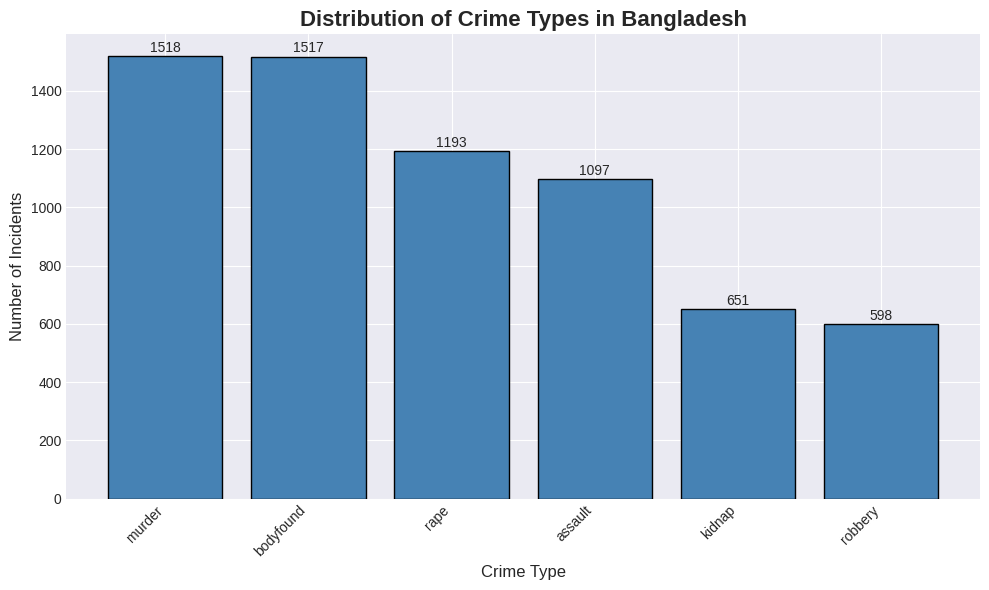


✓ Saved: 01_crime_distribution.png


In [ ]:
# Step 4: Analyze basic crime distribution

print("\n" + "=" * 60)
print("BASIC CRIME DISTRIBUTION")
print("=" * 60)

# Count crimes by type
crime_counts = df['crime'].value_counts()
print("\nCrime counts by type:")
print(crime_counts)

# Calculate percentages
crime_percentages = (crime_counts / len(df) * 100).round(1)
print("\nCrime percentages:")
for crime, count in crime_counts.items():
    print(f"  {crime}: {count} ({crime_percentages[crime]}%)")

# Create a simple bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(crime_counts.index, crime_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Crime Types in Bangladesh', fontsize=16, fontweight='bold')
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar, value in zip(bars, crime_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('01_crime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 01_crime_distribution.png")


CRIME ANALYSIS BY DIVISION

Crime counts by division:
incident_division
dhaka         2046
chattogram    1061
rajshahi       782
rangpur        703
khulna         697
mymensingh     449
sylhet         424
barisal        408
gazipur          4
dtype: int64

Detailed crime by division:
crime              assault  bodyfound  kidnap  murder  rape  robbery
incident_division                                                   
barisal                 97         70      31      86    97       27
chattogram             148        279     121     262   166       85
dhaka                  300        551     175     383   359      278
gazipur                  0          0       2       0     2        0
khulna                  94        125      79     201   140       58
mymensingh              66         93      40     158    74       18
rajshahi               148        183      77     207   114       53
rangpur                143        160      83     119   157       41
sylhet                 1

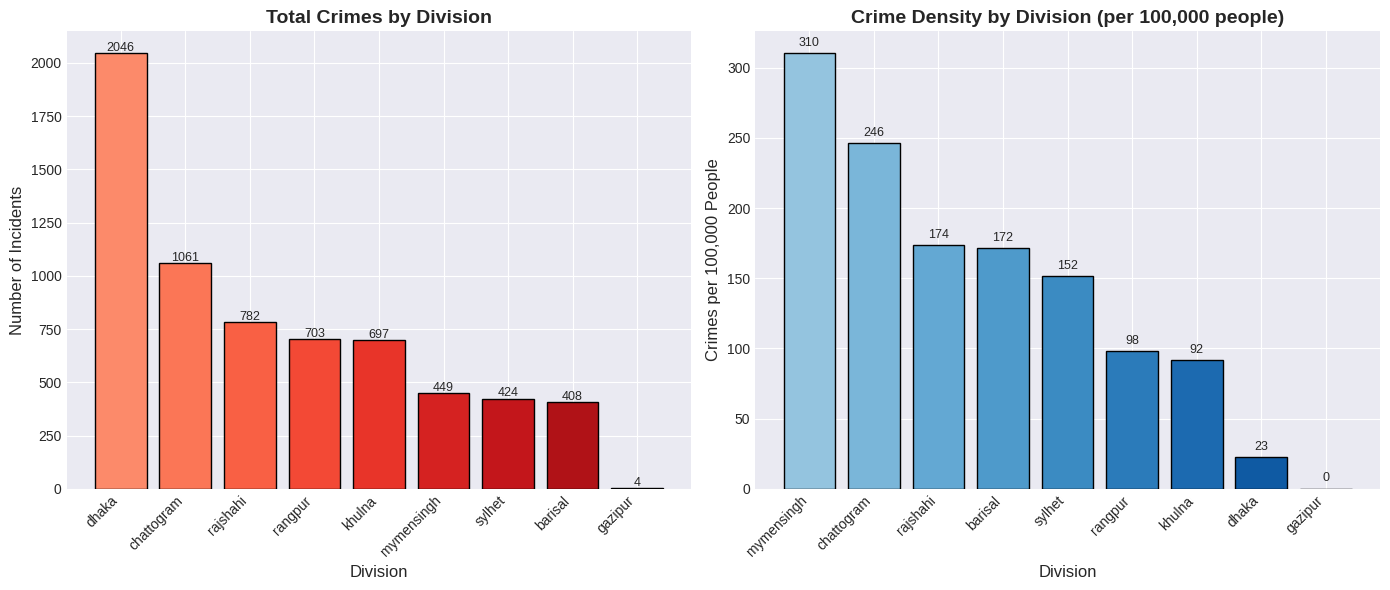


✓ Saved: 02_crime_by_division.png


In [ ]:
# Step 5: Analyze crime by division

print("\n" + "=" * 60)
print("CRIME ANALYSIS BY DIVISION")
print("=" * 60)

# Crime by division
division_crime = df.groupby('incident_division').size().sort_values(ascending=False)
print("\nCrime counts by division:")
print(division_crime)

# Detailed crime type by division
division_crime_type = pd.crosstab(df['incident_division'], df['crime'])
print("\nDetailed crime by division:")
print(division_crime_type)

# Calculate crime density (per population)
division_density = df.groupby('incident_division').agg({
    'crime': 'count',
    'total_population': 'first'
}).round(0)
division_density['crimes_per_100k'] = (division_density['crime'] / division_density['total_population'] * 100000).round(2)
division_density = division_density.sort_values('crimes_per_100k', ascending=False)

print("\nCrime density by division (per 100,000 people):")
print(division_density)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Total crimes by division
ax1 = axes[0]
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(division_crime)))
bars = ax1.bar(range(len(division_crime)), division_crime.values, color=colors, edgecolor='black')
ax1.set_title('Total Crimes by Division', fontsize=14, fontweight='bold')
ax1.set_xlabel('Division', fontsize=12)
ax1.set_ylabel('Number of Incidents', fontsize=12)
ax1.set_xticks(range(len(division_crime)))
ax1.set_xticklabels(division_crime.index, rotation=45, ha='right')
for bar, val in zip(bars, division_crime.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=9)

# Subplot 2: Crime density
ax2 = axes[1]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(division_density)))
bars2 = ax2.bar(range(len(division_density)), division_density['crimes_per_100k'].values, color=colors, edgecolor='black')
ax2.set_title('Crime Density by Division (per 100,000 people)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Division', fontsize=12)
ax2.set_ylabel('Crimes per 100,000 People', fontsize=12)
ax2.set_xticks(range(len(division_density)))
ax2.set_xticklabels(division_density.index, rotation=45, ha='right')
for bar, val in zip(bars2, division_density['crimes_per_100k'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_crime_by_division.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 02_crime_by_division.png")


CRIME ANALYSIS BY DISTRICT

Top 20 districts by total crime:
incident_district
dhaka           1169
chattogram       491
mymensingh       269
jashore          261
dinajpur         209
narayanganj      172
gazipur          170
pabna            169
bogura           166
sylhet           154
tangail          153
rajshahi         141
brahmanbaria     127
habiganj         121
rangpur          116
patuakhali       114
jamalpur         108
moulvibazar      107
faridpur         100
pirojpur          99
dtype: int64

Crime type breakdown for top 10 districts:
crime              assault  bodyfound  kidnap  murder  rape  robbery
incident_district                                                   
bogura                  28         34      26      31    28       19
chattogram              89        160      39     108    60       35
dhaka                  196        328      95     168   193      189
dinajpur                30         58      26      38    43       14
gazipur                 26   

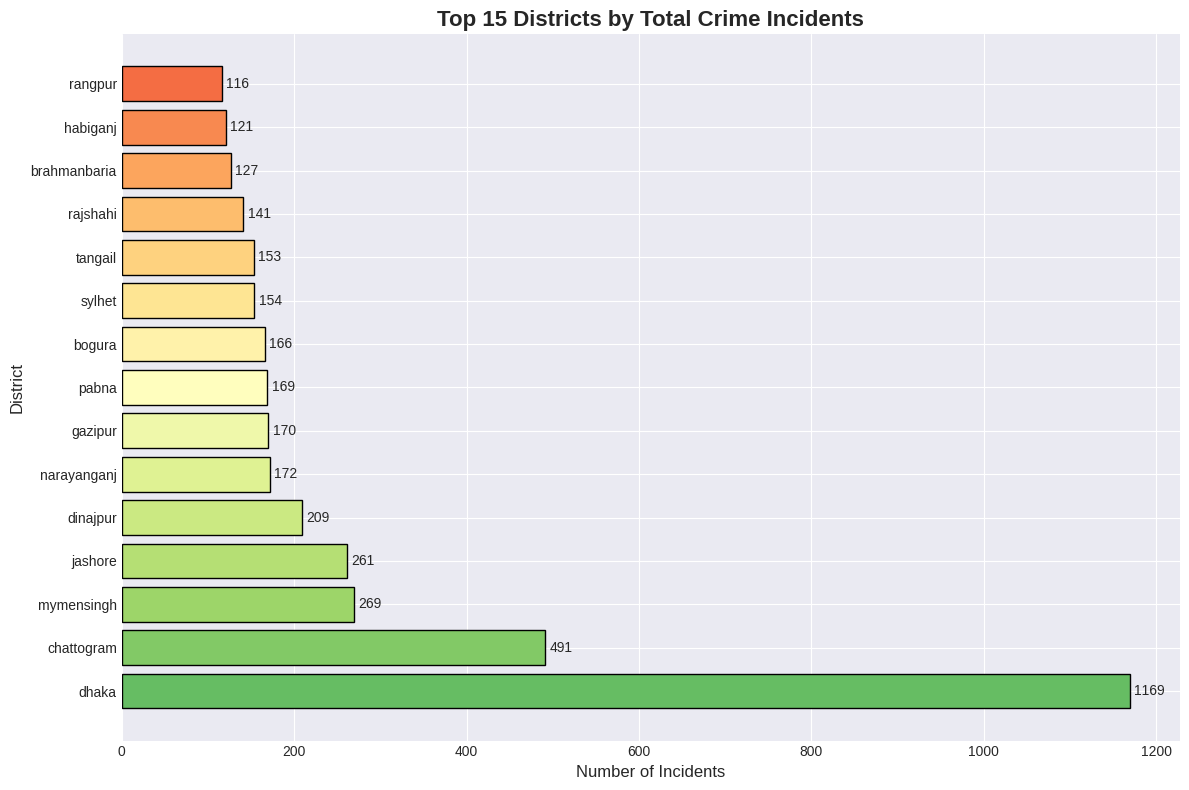


✓ Saved: 03_top_districts_crime.png

----------------------------------------
TOP SPECIFIC LOCATIONS WITH HIGHEST CRIME
----------------------------------------
  chattogram city: 224 incidents
  savar: 194 incidents
  sylhet sadar: 96 incidents
  rajshahi city: 85 incidents
  jessore sadar: 81 incidents
  gazipur sadar: 79 incidents
  narayanganj sadar: 77 incidents
  mirpur: 76 incidents
  mymensingh sadar: 72 incidents
  sharsha: 70 incidents
  bogra sadar: 61 incidents
  thakurgaon sadar: 61 incidents
  rangpur sadar: 50 incidents
  pabna sadar: 50 incidents
  lalmonirhat sadar: 45 incidents


In [ ]:
# Step 6: Analyze crime by district (most detailed area analysis)

print("\n" + "=" * 60)
print("CRIME ANALYSIS BY DISTRICT")
print("=" * 60)

# Top districts by total crime
district_crime = df.groupby('incident_district').size().sort_values(ascending=False)
print("\nTop 20 districts by total crime:")
print(district_crime.head(20))

# Crime type breakdown for top districts
top_districts = district_crime.head(10).index
district_crime_type = df[df['incident_district'].isin(top_districts)].groupby(['incident_district', 'crime']).size().unstack().fillna(0)
print("\nCrime type breakdown for top 10 districts:")
print(district_crime_type)

# Create visualization for top districts
plt.figure(figsize=(12, 8))
top_15 = district_crime.head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_15)))
bars = plt.barh(range(len(top_15)), top_15.values, color=colors, edgecolor='black')
plt.title('Top 15 Districts by Total Crime Incidents', fontsize=16, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.yticks(range(len(top_15)), top_15.index)

# Add value labels
for bar, val in zip(bars, top_15.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_top_districts_crime.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 03_top_districts_crime.png")

# Specific locations analysis
print("\n" + "-" * 40)
print("TOP SPECIFIC LOCATIONS WITH HIGHEST CRIME")
print("-" * 40)
location_crime = df.groupby('incident_place').size().sort_values(ascending=False).head(15)
for loc, count in location_crime.items():
    print(f"  {loc}: {count} incidents")


WEEKLY AND DAILY CRIME PATTERN ANALYSIS

----------------------------------------
CRIME BY WEEK OF THE YEAR
----------------------------------------

Crime counts by week (first 20 weeks):
incident_week
1     117
2     148
3     151
4     143
5     127
6     148
7     143
8     129
9     106
10    145
11    132
12    117
13    129
14    113
15    146
16    175
17    124
18    133
19    153
20    124
dtype: int64

Top 5 weeks with highest crime:
incident_week
16    175
33    173
42    159
22    155
19    153
dtype: int64

----------------------------------------
CRIME BY WEEKDAY
----------------------------------------

Crime counts by day of week:
  Monday: 984 incidents (15.0%)
  Tuesday: 1010 incidents (15.4%)
  Wednesday: 976 incidents (14.8%)
  Thursday: 937 incidents (14.3%)
  Friday: 883 incidents (13.4%)
  Saturday: 917 incidents (13.9%)
  Sunday: 867 incidents (13.2%)

🔥 MOST DANGEROUS DAY: TUESDAY with 1010 incidents

----------------------------------------
WEEKDAY VS WEEKEN

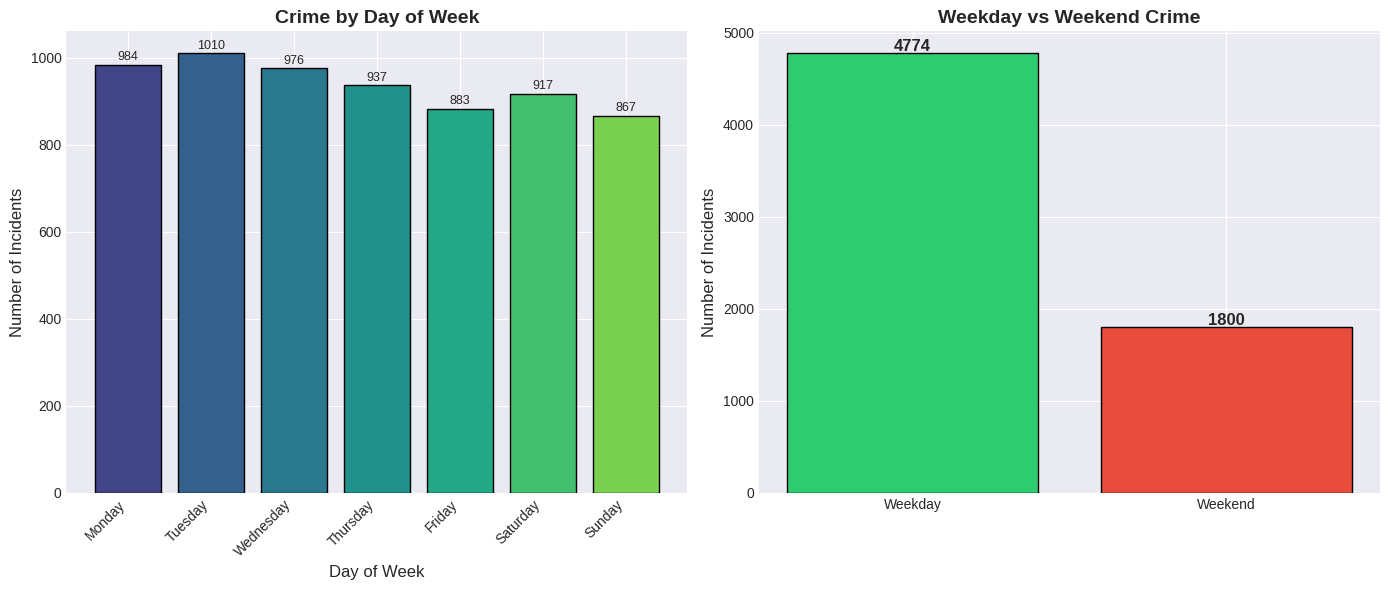


✓ Saved: 04_weekly_patterns.png

----------------------------------------
CRIME BY TIME OF DAY
----------------------------------------

Crime by time of day:
  Morning: 1975 incidents (30.0%)
  Afternoon: 336 incidents (5.1%)
  Evening: 492 incidents (7.5%)
  Night: 3244 incidents (49.3%)
  Noon: 527 incidents (8.0%)

🔥 MOST DANGEROUS TIME: NIGHT with 3244 incidents


In [ ]:
# Step 7: Analyze crime patterns by week and day

print("\n" + "=" * 60)
print("WEEKLY AND DAILY CRIME PATTERN ANALYSIS")
print("=" * 60)

# 7.1: Crime by Week of the year
print("\n" + "-" * 40)
print("CRIME BY WEEK OF THE YEAR")
print("-" * 40)

weekly_crime = df.groupby('incident_week').size().sort_index()
print("\nCrime counts by week (first 20 weeks):")
print(weekly_crime.head(20))

# Find weeks with highest crime
print("\nTop 5 weeks with highest crime:")
print(weekly_crime.sort_values(ascending=False).head(5))

# 7.2: Crime by Weekday
print("\n" + "-" * 40)
print("CRIME BY WEEKDAY")
print("-" * 40)

weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
weekday_counts = df.groupby('incident_weekday').size().reindex(weekday_order)
print("\nCrime counts by day of week:")
for day, count in weekday_counts.items():
    percentage = round((count / len(df) * 100), 1)
    print(f"  {day.capitalize()}: {count} incidents ({percentage}%)")

# Find most dangerous day
most_dangerous_day = weekday_counts.idxmax()
print(f"\n🔥 MOST DANGEROUS DAY: {most_dangerous_day.upper()} with {weekday_counts.max()} incidents")

# 7.3: Weekday vs Weekend comparison
print("\n" + "-" * 40)
print("WEEKDAY VS WEEKEND COMPARISON")
print("-" * 40)

weekday_total = df[df['weekend'] == 0].shape[0]
weekend_total = df[df['weekend'] == 1].shape[0]
print(f"Weekday incidents: {weekday_total}")
print(f"Weekend incidents: {weekend_total}")
print(f"Weekend percentage: {(weekend_total/len(df)*100):.1f}%")

# Create visualization for weekday patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Crime by weekday
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(weekday_counts)))
bars = ax1.bar(range(len(weekday_counts)), weekday_counts.values, color=colors, edgecolor='black')
ax1.set_title('Crime by Day of Week', fontsize=14, fontweight='bold')
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Number of Incidents', fontsize=12)
ax1.set_xticks(range(len(weekday_counts)))
ax1.set_xticklabels([d.capitalize() for d in weekday_counts.index], rotation=45, ha='right')
for bar, val in zip(bars, weekday_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=9)

# Subplot 2: Weekday vs Weekend
ax2 = axes[1]
wed_weekend_data = [weekday_total, weekend_total]
colors2 = ['#2ecc71', '#e74c3c']
bars2 = ax2.bar(['Weekday', 'Weekend'], wed_weekend_data, color=colors2, edgecolor='black')
ax2.set_title('Weekday vs Weekend Crime', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Incidents', fontsize=12)
for bar, val in zip(bars2, wed_weekend_data):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('04_weekly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 04_weekly_patterns.png")

# 7.4: Time of day analysis
print("\n" + "-" * 40)
print("CRIME BY TIME OF DAY")
print("-" * 40)

time_order = ['morning', 'afternoon', 'evening', 'night', 'noon']
time_counts = df.groupby('part_of_the_day').size().reindex(time_order)
print("\nCrime by time of day:")
for time, count in time_counts.items():
    percentage = round((count / len(df) * 100), 1) if count > 0 else 0
    print(f"  {time.capitalize()}: {count} incidents ({percentage}%)")

most_dangerous_time = time_counts.idxmax()
print(f"\n🔥 MOST DANGEROUS TIME: {most_dangerous_time.upper()} with {time_counts.max()} incidents")

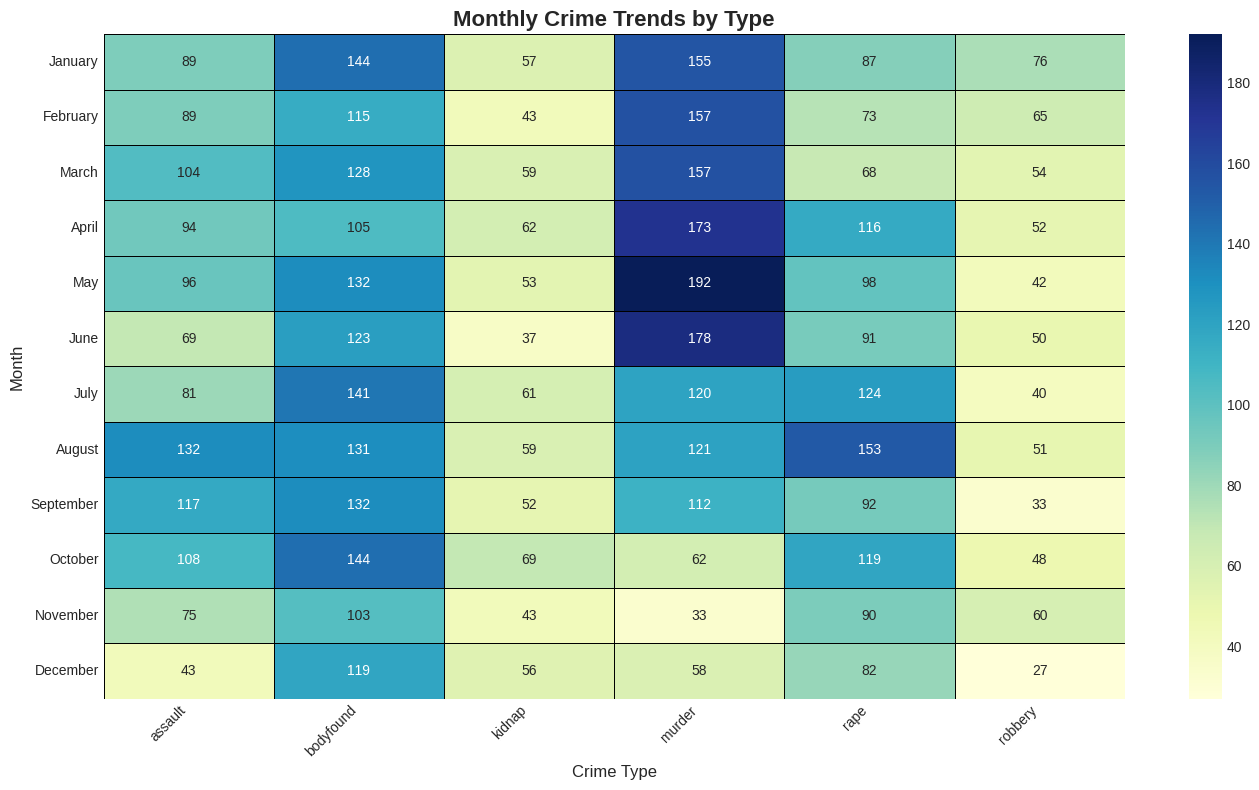

✓ Saved: 07_monthly_crime_type_heatmap.png


In [ ]:
# Group by month and crime type, then count incidents
monthly_crime_type_counts = df.groupby(['incident_month', 'crime']).size().unstack(fill_value=0)

# Map month numbers to names for better readability on the heatmap
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_crime_type_counts.index = monthly_crime_type_counts.index.map(lambda x: month_names_full[x-1])

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_crime_type_counts, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Monthly Crime Trends by Type', fontsize=16, fontweight='bold')
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('07_monthly_crime_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 07_monthly_crime_type_heatmap.png")


WEATHER IMPACT ON CRIME

Crime on rainy vs non-rainy days:
  Rainy days (>0mm): 3958 incidents
  Non-rainy days (0mm): 2616 incidents
  Rainy day incidents: 60.2% of total

Temperature statistics by crime type:
           mean  min  max
crime                    
assault    29.4   20   40
bodyfound  29.0   16   40
kidnap     29.1   20   39
murder     29.7   19   39
rape       29.1   18   40
robbery    28.4   17   37

Crime by humidity level:
  Low (<50%): 1389 incidents
  Moderate (50-70%): 2286 incidents
  High (70-85%): 2563 incidents
  Very High (>85%): 336 incidents


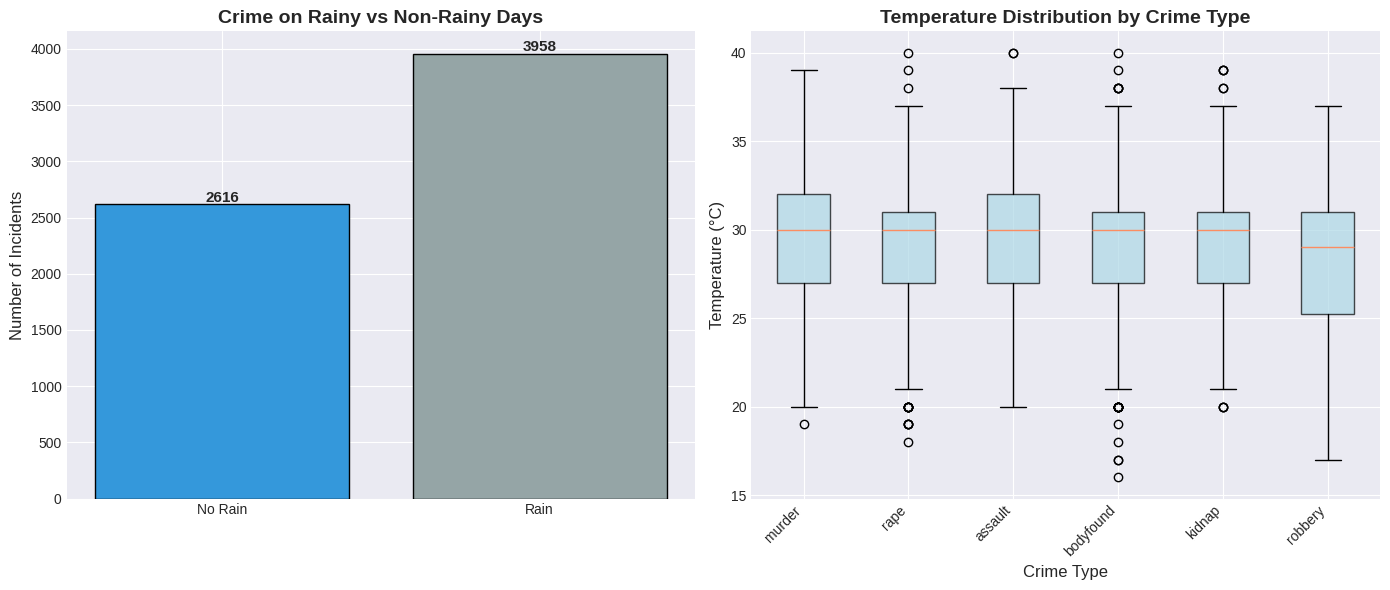


✓ Saved: 06_weather_impact.png


In [ ]:
# Step 9: Analyze weather impact on crime

print("\n" + "=" * 60)
print("WEATHER IMPACT ON CRIME")
print("=" * 60)

# 9.1: Rainy vs Non-rainy days
df['is_rainy'] = df['precip'] > 0
rainy_crime = df.groupby('is_rainy').size()
print("\nCrime on rainy vs non-rainy days:")
print(f"  Rainy days (>0mm): {rainy_crime.get(True, 0)} incidents")
print(f"  Non-rainy days (0mm): {rainy_crime.get(False, 0)} incidents")

if rainy_crime.get(True, 0) > 0:
    rainy_pct = (rainy_crime.get(True, 0) / len(df) * 100)
    print(f"  Rainy day incidents: {rainy_pct:.1f}% of total")

# 9.2: Temperature analysis
print("\nTemperature statistics by crime type:")
temp_stats = df.groupby('crime')['avg_temp'].agg(['mean', 'min', 'max']).round(1)
print(temp_stats)

# 9.3: Humidity analysis
df['humidity_category'] = pd.cut(df['humidity'],
                                  bins=[0, 50, 70, 85, 100],
                                  labels=['Low (<50%)', 'Moderate (50-70%)', 'High (70-85%)', 'Very High (>85%)'])
humidity_crime = df.groupby('humidity_category').size()
print("\nCrime by humidity level:")
for level, count in humidity_crime.items():
    if count > 0:
        print(f"  {level}: {count} incidents")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Rain impact
ax1 = axes[0]
rain_data = [rainy_crime.get(False, 0), rainy_crime.get(True, 0)]
bars = ax1.bar(['No Rain', 'Rain'], rain_data, color=['#3498db', '#95a5a6'], edgecolor='black')
ax1.set_title('Crime on Rainy vs Non-Rainy Days', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Incidents', fontsize=12)
for bar, val in zip(bars, rain_data):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=11, fontweight='bold')

# Subplot 2: Temperature by crime type (boxplot)
ax2 = axes[1]
crime_list = df['crime'].unique()
temp_data = [df[df['crime'] == crime]['avg_temp'].dropna() for crime in crime_list]
bp = ax2.boxplot(temp_data, labels=crime_list, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('lightblue')
    box.set_alpha(0.7)
ax2.set_title('Temperature Distribution by Crime Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Crime Type', fontsize=12)
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.set_xticklabels(crime_list, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('06_weather_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 06_weather_impact.png")